In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [2]:
df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [3]:
df.shape # each image have 28*28 = 784 pixels, and each pixel is dhown as colunn
# 42000 images * 785 (pixels + 1 label col) 

(42000, 785)

In [4]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
10288,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
import matplotlib.pyplot as plt

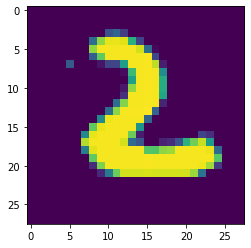

In [6]:
plt.imshow(df.iloc[32515,1:].values.reshape(28,28))

In [7]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train.shape

(33600, 784)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
knn = KNeighborsClassifier()

In [12]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [13]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

9.376850605010986


In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [16]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # mean centring before PCA

In [17]:
# PCA 
from sklearn.decomposition import PCA
pca = PCA(n_components=200) # Number of Principle components

In [18]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [19]:
X_train_trf.shape

(33600, 200)

In [20]:
knn = KNeighborsClassifier()

In [21]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [22]:
y_pred = knn.predict(X_test_trf)

In [23]:
accuracy_score(y_test,y_pred)

0.9513095238095238

In [24]:
# for i in range(1,785):
#     pca = PCA(n_components=i)
#     X_train_trf = pca.fit_transform(X_train)
#     X_test_trf = pca.transform(X_test)
    
#     knn = KNeighborsClassifier()
    
#     knn.fit(X_train_trf,y_train)
    
#     y_pred = knn.predict(X_test_trf)
    
#     print(accuracy_score(y_test,y_pred))
    

In [25]:
# transforming to a 2D coordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [26]:
X_train_trf

array([[-2.71859449, -0.48918422],
       [-0.67700774, -6.75402172],
       [-3.0332428 ,  6.50946823],
       ...,
       [ 2.1488089 ,  0.7800902 ],
       [ 1.05961976,  0.9485523 ],
       [17.70260915,  1.96219343]])

In [27]:
# Install (just in case — usually already installed in Kaggle)
# !pip install plotly -q

# Imports
import plotly.express as px
import plotly.io as pio

# Force a reliable renderer
pio.renderers.default = "iframe"

# Convert labels to string (for coloring)
y_train_trf = y_train.astype(str)

# Handle both NumPy array and DataFrame cases
try:
    x_vals = X_train_trf[:, 0]
    y_vals = X_train_trf[:, 1]
except:
    x_vals = X_train_trf.iloc[:, 0]
    y_vals = X_train_trf.iloc[:, 1]

# Create plot
fig = px.scatter(
    x=x_vals,
    y=y_vals,
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

# Show plot
fig.show()

# Backup (always works)
fig.write_html("plot.html")
print("If plot not visible, open plot.html from Kaggle file panel.")

If plot not visible, open plot.html from Kaggle file panel.


In [28]:
# transforming in 3D
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [29]:
X_train_trf

array([[-2.71860615, -0.48940581,  1.13513991],
       [-0.67699216, -6.75351266, -2.3363113 ],
       [-3.03324063,  6.50967201,  7.49238817],
       ...,
       [ 2.1488364 ,  0.78052551, -0.74729953],
       [ 1.05961749,  0.94811386,  3.94953237],
       [17.70259717,  1.96199269, -4.94345112]])

In [30]:
# Install (safe)
# !pip install plotly -q

# Imports
import plotly.express as px
import plotly.io as pio

# Force renderer (VERY IMPORTANT for Kaggle)
pio.renderers.default = "iframe"

# Convert labels
y_train_trf = y_train.astype(str)

# Handle NumPy / DataFrame both cases
try:
    x_vals = X_train_trf[:, 0]
    y_vals = X_train_trf[:, 1]
    z_vals = X_train_trf[:, 2]
except:
    x_vals = X_train_trf.iloc[:, 0]
    y_vals = X_train_trf.iloc[:, 1]
    z_vals = X_train_trf.iloc[:, 2]

# Create 3D scatter (NO df here)
fig = px.scatter_3d(
    x=x_vals,
    y=y_vals,
    z=z_vals,
    color=y_train_trf
)

# Layout
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)

# Show
fig.show()

# Backup (always works)
fig.write_html("plot3d.html")
print("If not visible, open plot3d.html from file panel.")

If not visible, open plot3d.html from file panel.


In [31]:
pca.explained_variance_
# Eigen values

array([40.67111198, 29.17023394, 26.74459606])

In [32]:
pca.components_
# Eigen vectors

array([[ 1.61082165e-17,  9.55228671e-20, -2.28768038e-20, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-3.65645569e-17,  2.34887783e-17, -7.27703175e-18, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 4.46186740e-17,  2.90158499e-17, -1.33515976e-17, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [33]:
pca.components_.shape
# Eigen vectors

(3, 784)

In [34]:
pca.explained_variance_ratio_  # these are the ratio of the variance captured by the 3 eigen vectors

array([0.05785192, 0.0414927 , 0.03804239])

# To find the optimum no. of PC
- Do PCA with n_component =none
- Apply cumulative sum to the explained_variance_ratio_ and see at what no. of PC 90% of variance is captured/explained
- Plot the graph to see at what no. of PC 90% variance is captured
  

In [35]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [36]:
pca.explained_variance_.shape

(784,)

In [37]:
pca.components_.shape

(784, 784)

In [38]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

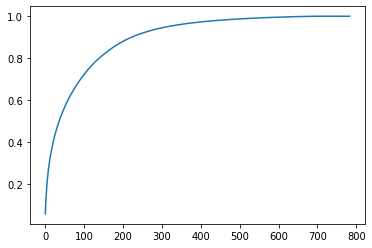

In [39]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))